# `PyTorch` without `torchvision`

Educational CNN on a curated flower-photo subset (`data/flower_photos_mini`). No Colab / Drive mount required.

### (i) Preprocessor and Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from skimage.io import imread
from skimage.transform import resize
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import BatchNorm2d, Conv2d, CrossEntropyLoss, Linear, MaxPool2d, ReLU, Sequential
from torch.optim import Adam
from tqdm import tqdm

DATA_ROOT = Path("data/flower_photos_mini")
TRAIN_DIR = DATA_ROOT / "training_set"
TEST_DIR = DATA_ROOT / "test_set"
IMG_SIZE = 64
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ["tulips", "daisy", "dandelion", "sunflowers", "roses"]
label_map = {name: i for i, name in enumerate(CLASS_NAMES)}
inv_label = {i: name for name, i in label_map.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [2]:
train = pd.read_csv(TRAIN_DIR / "training.csv")
train = train.rename(columns={"Id": "id"})
train["label"] = train["label"].map(label_map)
train.head()


,label,id,image_type
0,1,1031799732_e7f4008c03,.jpg
1,1,10437770546_8bb6f7bdd3_m,.jpg
2,1,105806915_a9c13e2106_n,.jpg
3,1,10993710036_2033222c91,.jpg
4,1,12348343085_d4c396e5b5_m,.jpg


#### Preprocessor

In [3]:
def preprocessor(data_path: Path, labels_df: pd.DataFrame) -> list[np.ndarray]:
    """Read images, resize to a fixed shape, and min-max scale to [0, 1].

    Parameters
    ----------
    data_path:
        Directory containing image files.
    labels_df:
        DataFrame with columns ``id`` and ``image_type`` (extension).

    Returns
    -------
    list[np.ndarray]
        List of float32 HWC arrays.
    """
    images: list[np.ndarray] = []
    for _, row in tqdm(labels_df.iterrows(), total=len(labels_df)):
        path = data_path / f"{row['id']}{row['image_type']}"
        img = imread(path)
        img = resize(img, (IMG_SIZE, IMG_SIZE, 3), anti_aliasing=True)
        img = img.astype("float32")
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        images.append(img)
    return images

train_x = np.asarray(preprocessor(TRAIN_DIR, train), dtype=np.float32)
train_y = train["label"].to_numpy(dtype=np.int64)
train_x.shape, train_y.shape


  0%|          | 0/400 [00:00<?, ?it/s]

  3%|▎         | 13/400 [00:00<00:03, 127.21it/s]

  8%|▊         | 31/400 [00:00<00:02, 155.51it/s]

 12%|█▎        | 50/400 [00:00<00:02, 167.16it/s]

 18%|█▊        | 70/400 [00:00<00:01, 176.44it/s]

...

 89%|████████▉ | 355/400 [00:02<00:00, 155.45it/s]

 93%|█████████▎| 371/400 [00:02<00:00, 149.44it/s]

 97%|█████████▋| 389/400 [00:02<00:00, 154.99it/s]

100%|██████████| 400/400 [00:02<00:00, 158.83it/s]

((400, 64, 64, 3), (400,))

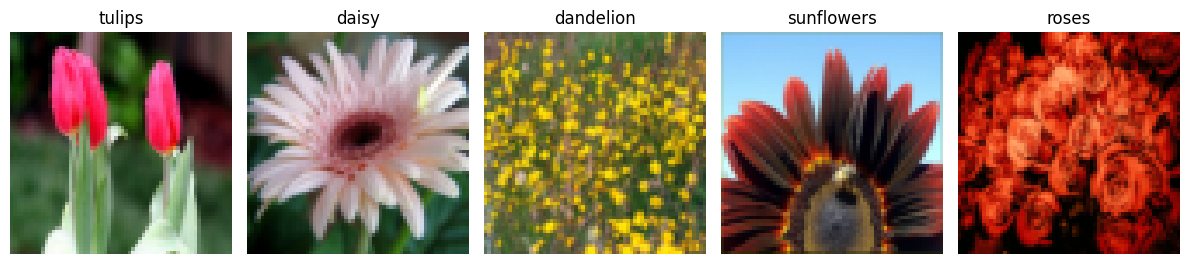

In [4]:
# One example per class from the training tensors
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, class_id in zip(axes, range(5)):
    idx = int(np.where(train_y == class_id)[0][0])
    ax.imshow(train_x[idx])
    ax.set_title(inv_label[class_id])
    ax.axis("off")
plt.tight_layout()
plt.show()


In [5]:
train_x, val_x, train_y, val_y = train_test_split(
    train_x, train_y, test_size=0.2, random_state=SEED, stratify=train_y
)
train_x.shape, val_x.shape, train_y.shape, val_y.shape


((320, 64, 64, 3), (80, 64, 64, 3), (320,), (80,))

In [6]:
# NHWC -> NCHW tensors
train_x_t = torch.from_numpy(np.transpose(train_x, (0, 3, 1, 2)))
val_x_t = torch.from_numpy(np.transpose(val_x, (0, 3, 1, 2)))
train_y_t = torch.from_numpy(train_y)
val_y_t = torch.from_numpy(val_y)

from torch.utils.data import DataLoader, TensorDataset

batch_size = 32
train_loader = DataLoader(
    TensorDataset(train_x_t, train_y_t), batch_size=batch_size, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(val_x_t, val_y_t), batch_size=batch_size, shuffle=False
)
train_x_t.shape, train_y_t.shape, val_x_t.shape, val_y_t.shape


(torch.Size([320, 3, 64, 64]),
 torch.Size([320]),
 torch.Size([80, 3, 64, 64]),
 torch.Size([80]))

### (ii) Train Model Using `torch`

In [7]:
class Net(nn.Module):
    def __init__(self, n_classes: int = 5) -> None:
        super().__init__()
        self.cnn_layers = Sequential(
            Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
            BatchNorm2d(16),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=2, stride=2),
            Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            BatchNorm2d(32),
            ReLU(inplace=True),
            MaxPool2d(kernel_size=2, stride=2),
        )
        # 64 -> 32 -> 16
        self.linear_layers = Sequential(Linear(32 * 16 * 16, n_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn_layers(x)
        x = x.reshape(x.size(0), -1)
        return self.linear_layers(x)

model = Net().to(device)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = CrossEntropyLoss()
print(model)


Net(
  (cnn_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layers): Sequential(
    (0): Linear(in_features=8192, out_features=5, bias=True)
  )
)


In [8]:
def run_loader(loader: DataLoader, train_mode: bool) -> tuple[float, float]:
    if train_mode:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        with torch.set_grad_enabled(train_mode):
            logits = model(xb)
            loss = criterion(logits, yb)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * yb.size(0)
        total_correct += (logits.argmax(dim=1) == yb).sum().item()
        total_n += yb.size(0)
    return total_loss / total_n, total_correct / total_n

n_epochs = 40
train_losses: list[float] = []
val_losses: list[float] = []
for epoch in range(n_epochs):
    tr_loss, tr_acc = run_loader(train_loader, train_mode=True)
    va_loss, va_acc = run_loader(val_loader, train_mode=False)
    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(
            f"epoch={epoch+1:02d}  train_loss={tr_loss:.3f}  val_loss={va_loss:.3f}  "
            f"train_acc={tr_acc:.2f}  val_acc={va_acc:.2f}"
        )


epoch=01  train_loss=3.321  val_loss=1.527  train_acc=0.29  val_acc=0.28


epoch=06  train_loss=0.517  val_loss=1.362  train_acc=0.84  val_acc=0.50


epoch=11  train_loss=0.187  val_loss=1.536  train_acc=0.97  val_acc=0.53


epoch=16  train_loss=0.063  val_loss=1.787  train_acc=1.00  val_acc=0.54


epoch=21  train_loss=0.032  val_loss=1.835  train_acc=1.00  val_acc=0.53


epoch=26  train_loss=0.019  val_loss=1.974  train_acc=1.00  val_acc=0.53


epoch=31  train_loss=0.015  val_loss=2.041  train_acc=1.00  val_acc=0.53


epoch=36  train_loss=0.013  val_loss=2.130  train_acc=1.00  val_acc=0.53


epoch=40  train_loss=0.008  val_loss=2.167  train_acc=1.00  val_acc=0.53


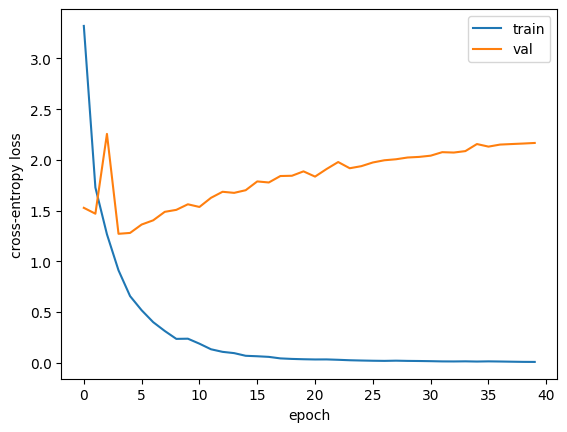

train accuracy (split) 1.0
val accuracy (split) 0.525


  0%|          | 0/100 [00:00<?, ?it/s]

 18%|█▊        | 18/100 [00:00<00:00, 172.89it/s]

 36%|███▌      | 36/100 [00:00<00:00, 138.38it/s]

 51%|█████     | 51/100 [00:00<00:00, 137.13it/s]

 66%|██████▌   | 66/100 [00:00<00:00, 137.84it/s]

 82%|████████▏ | 82/100 [00:00<00:00, 144.20it/s]

 97%|█████████▋| 97/100 [00:00<00:00, 144.57it/s]

100%|██████████| 100/100 [00:00<00:00, 140.90it/s]

holdout accuracy (test_set) 0.49


In [9]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.legend()
plt.show()

model.eval()
with torch.no_grad():
    train_pred = model(train_x_t.to(device)).argmax(dim=1).cpu().numpy()
    val_pred = model(val_x_t.to(device)).argmax(dim=1).cpu().numpy()
print("train accuracy (split)", accuracy_score(train_y, train_pred))
print("val accuracy (split)", accuracy_score(val_y, val_pred))

holdout = pd.read_csv(TEST_DIR / "testing.csv").rename(columns={"Id": "id"})
holdout["label"] = holdout["label"].map(label_map)
holdout_x = np.asarray(preprocessor(TEST_DIR, holdout), dtype=np.float32)
holdout_y = holdout["label"].to_numpy(dtype=np.int64)
holdout_x_t = torch.from_numpy(np.transpose(holdout_x, (0, 3, 1, 2)))
with torch.no_grad():
    holdout_pred = model(holdout_x_t.to(device)).argmax(dim=1).cpu().numpy()
print("holdout accuracy (test_set)", accuracy_score(holdout_y, holdout_pred))


### Notes

- Class indices are **0–4** (`tulips`, `daisy`, `dandelion`, `sunflowers`, `roses`) for `CrossEntropyLoss`.
- Training monitors an 80/20 split of `training_set`; reported **holdout** accuracy uses `test_set`.
